Using kaggle-drdataboston resampled_subjects
We will try to apply different transformations to the step data to count steps

In [33]:

# Set your filename here
filename = '../data/kaggle-drdataboston/resampled_subjects/sub1-lw-s1.csv'

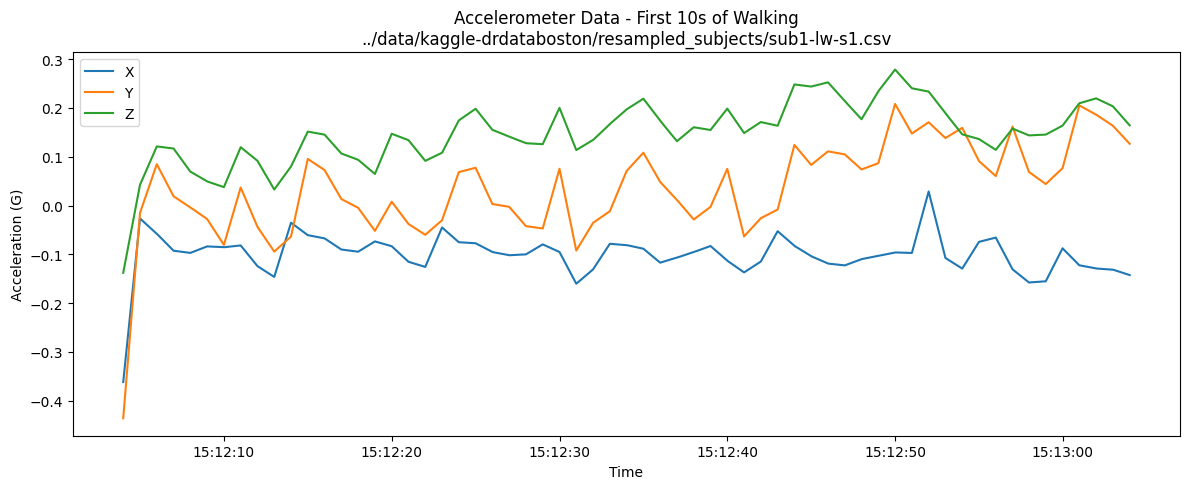

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal


# Load data
df = pd.read_csv(filename)

# Convert timestamp to datetime if needed
df['timestamp_50Hz'] = pd.to_datetime(df['timestamp_50Hz'])

# Sampling frequency and time window
fs = 50
seconds = 60
samples = fs * seconds

# Get first 10 seconds
df_10s = df.iloc[:samples]

# Plot
plt.figure(figsize=(12, 5))
plt.plot(df_10s['timestamp_50Hz'], df_10s['motionUserAccelerationX.G.'], label='X')
plt.plot(df_10s['timestamp_50Hz'], df_10s['motionUserAccelerationY.G.'], label='Y')
plt.plot(df_10s['timestamp_50Hz'], df_10s['motionUserAccelerationZ.G.'], label='Z')
plt.xlabel('Time')
plt.ylabel('Acceleration (G)')
plt.title(f'Accelerometer Data - First 10s of Walking\n{filename}')
plt.legend()
plt.tight_layout()
plt.show()


           start_time                end_time  estimated_steps  \
0 2017-11-13 15:12:04 2017-11-13 15:13:03.980               41   
1 2017-11-13 15:13:04 2017-11-13 15:14:03.980               40   
2 2017-11-13 15:14:04 2017-11-13 15:15:03.980               38   
3 2017-11-13 15:15:04 2017-11-13 15:16:03.980               43   
4 2017-11-13 15:16:04 2017-11-13 15:17:03.980               15   
5 2017-11-13 15:17:04 2017-11-13 15:18:03.980               36   
6 2017-11-13 15:18:04 2017-11-13 15:19:03.980               41   
7 2017-11-13 15:19:04 2017-11-13 15:20:03.980               39   
8 2017-11-13 15:20:04 2017-11-13 15:21:03.980               39   

   pedometer_steps  difference  
0             97.0        56.0  
1             90.0        50.0  
2            112.0        74.0  
3            112.0        69.0  
4              NaN         NaN  
5              NaN         NaN  
6            112.0        71.0  
7            110.0        71.0  
8            111.0        72.0  


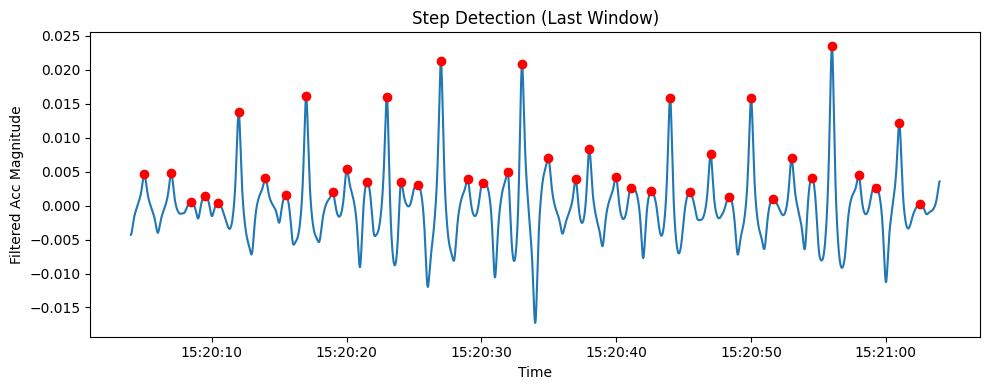

In [35]:
from scipy.signal import savgol_filter

results = []

# Compute acceleration magnitude
acc_mag = np.sqrt(
    df['motionUserAccelerationX.G.']**2 +
    df['motionUserAccelerationY.G.']**2 +
    df['motionUserAccelerationZ.G.']**2
)

# Apply bandpass filter
lowcut, highcut = 0.5, 3.0
b, a = signal.butter(2, [lowcut / (fs/2), highcut / (fs/2)], btype='band')
acc_filt = signal.filtfilt(b, a, acc_mag)



# Iterate through 10-second chunks
num_chunks = len(df) // samples

for i in range(num_chunks):
    start_idx = i * samples
    end_idx = (i + 1) * samples

    chunk = df.iloc[start_idx:end_idx]
    chunk_filt = acc_filt[start_idx:end_idx]

    # Skip incomplete or empty chunks
    if chunk.empty or len(chunk) < samples:
        continue

    # Detect steps
    peaks, _ = signal.find_peaks(chunk_filt, distance=fs*0.4)
    est_steps = len(peaks)

    # Compute pedometer steps difference in this window
    pedo_start = chunk['pedometerNumberofSteps.N.'].iloc[0]
    pedo_end = chunk['pedometerNumberofSteps.N.'].iloc[-1]
    pedo_steps = pedo_end - pedo_start

    results.append({
        'start_time': chunk['timestamp_50Hz'].iloc[0],
        'end_time': chunk['timestamp_50Hz'].iloc[-1],
        'estimated_steps': est_steps,
        'pedometer_steps': pedo_steps,
        'difference': abs(est_steps - pedo_steps)
    })

# Convert results to DataFrame
step_df = pd.DataFrame(results)

# Show results
print(step_df)

# Optional: plot one segment for visual check
if not step_df.empty:
    plt.figure(figsize=(10, 4))
    plt.plot(chunk['timestamp_50Hz'], chunk_filt)
    plt.plot(chunk['timestamp_50Hz'].iloc[peaks], chunk_filt[peaks], 'ro')
    plt.title('Step Detection (Last Window)')
    plt.xlabel('Time')
    plt.ylabel('Filtered Acc Magnitude')
    plt.tight_layout()
    plt.show()

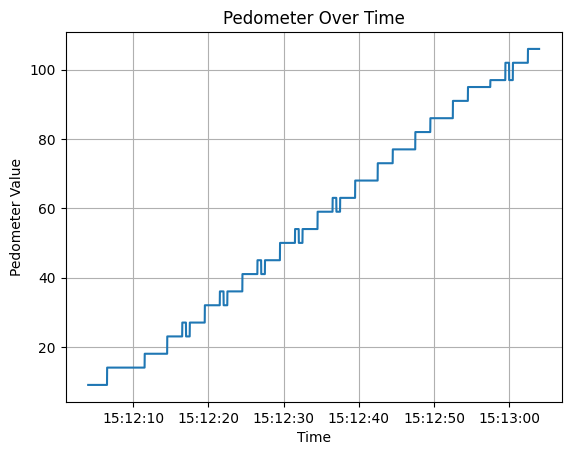

In [36]:
import matplotlib.pyplot as plt

no = 50 * 60
plt.plot(df['timestamp_50Hz'][:no], df['pedometerNumberofSteps.N.'][:no])
plt.xlabel("Time")
plt.ylabel("Pedometer Value")
plt.title("Pedometer Over Time")
plt.grid(True)
plt.show()


📟 Pedometer steps: 918.0
🦶 Estimated steps (hybrid): 364
🔍 Difference: 554.0


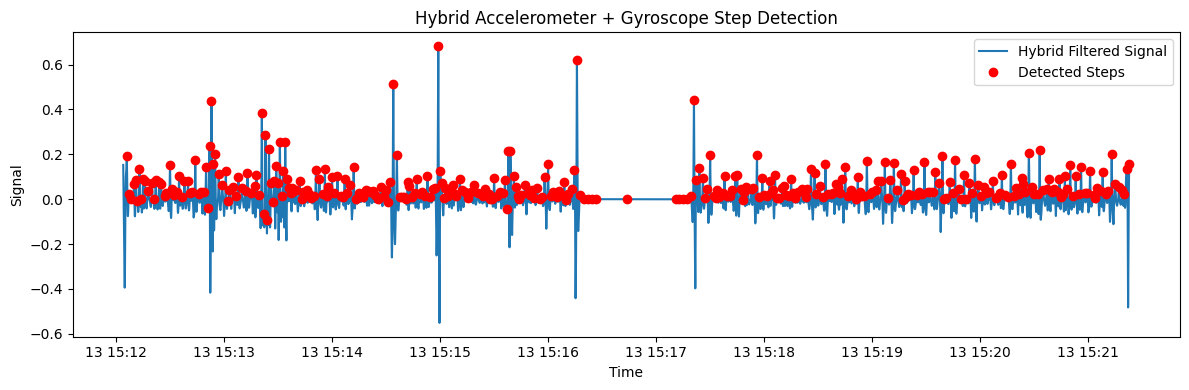

In [37]:


# === Step 1: Compute magnitudes ===
acc_mag = np.sqrt(
    df['motionUserAccelerationX.G.']**2 +
    df['motionUserAccelerationY.G.']**2 +
    df['motionUserAccelerationZ.G.']**2
)

gyro_mag = np.sqrt(
    df['gyroRotationX.rad.s.']**2 +
    df['gyroRotationY.rad.s.']**2 +
    df['gyroRotationZ.rad.s.']**2
)

# === Step 2: Normalize (optional but good if units differ) ===
acc_norm = (acc_mag - acc_mag.mean()) / acc_mag.std()
gyro_norm = (gyro_mag - gyro_mag.mean()) / gyro_mag.std()

# === Step 3: Combine ===
combined = 0.6 * acc_norm + 0.4 * gyro_norm

# === Step 4: Bandpass filter (0.5–3 Hz) ===
lowcut, highcut = 0.5, 3.0
b, a = signal.butter(2, [lowcut / (fs/2), highcut / (fs/2)], btype='band')
combined_filt = signal.filtfilt(b, a, combined)

# === Step 5: Peak detection ===
peaks, _ = signal.find_peaks(combined_filt, distance=fs*0.4)

# === Step 6: Pedometer true steps ===
actual_steps = df['pedometerNumberofSteps.N.'].iloc[-1] - df['pedometerNumberofSteps.N.'].iloc[0]
estimated_steps = len(peaks)

# === Print summary ===
print(f"📟 Pedometer steps: {actual_steps}")
print(f"🦶 Estimated steps (hybrid): {estimated_steps}")
print(f"🔍 Difference: {abs(actual_steps - estimated_steps)}")

# === Plot ===
plt.figure(figsize=(12, 4))
plt.plot(df['timestamp_50Hz'], combined_filt, label='Hybrid Filtered Signal')
plt.plot(df['timestamp_50Hz'].iloc[peaks], combined_filt[peaks], 'ro', label='Detected Steps')
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Hybrid Accelerometer + Gyroscope Step Detection')
plt.legend()
plt.tight_layout()
plt.show()
